In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/Titanic-Dataset (1).csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

missing_data.head(5)

,Total,Percent
Cabin,687,0.771044
Age,177,0.198653
Embarked,2,0.002245
PassengerId,0,0.000000
Name,0,0.000000


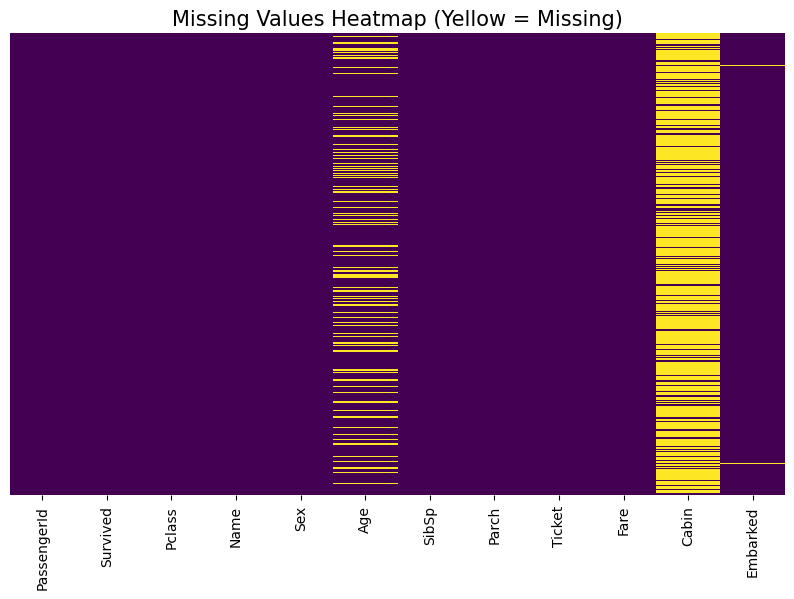

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=15)
plt.show()

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col',
 	'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

df[['Name', 'Title', 'FamilySize']].head()

,Name,Title,FamilySize
0,"Braund, Mr. Owen Harris",Mr,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2
2,"Heikkinen, Miss. Laina",Miss,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2
4,"Allen, Mr. William Henry",Mr,1


/tmp/ipykernel_6430/2125098978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='viridis', ax=ax[0])


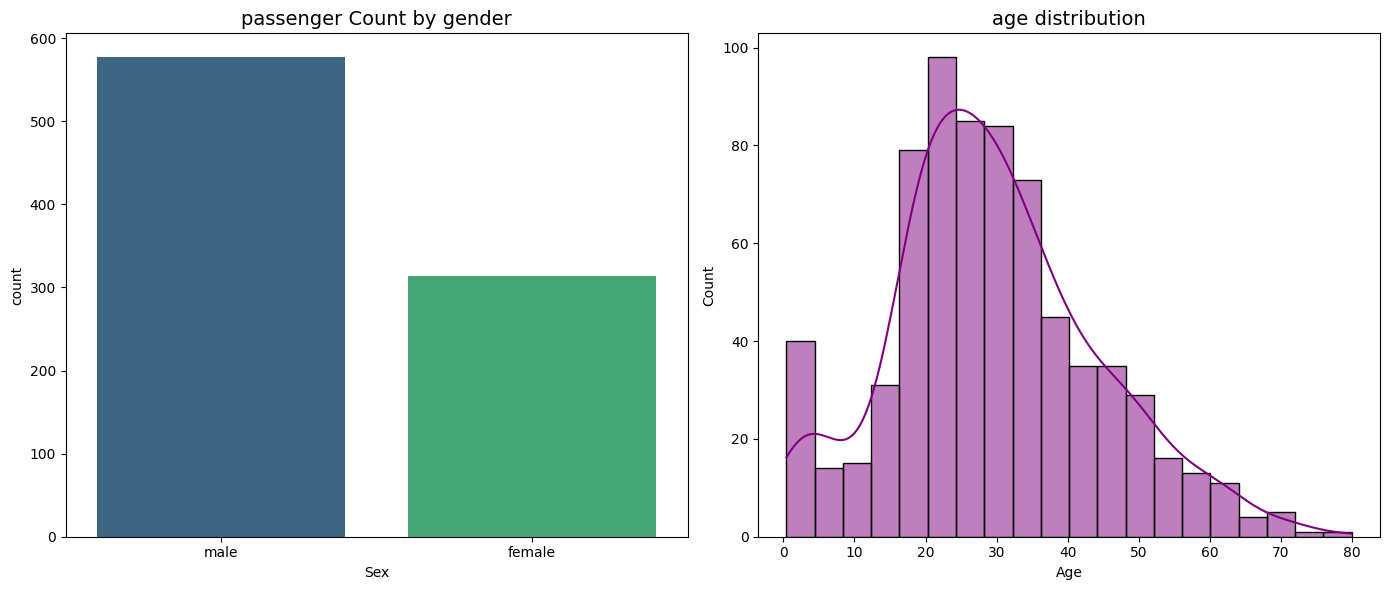

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df, x='Sex', palette='viridis', ax=ax[0])
ax[0].set_title('passenger Count by gender', fontsize=14)

sns.histplot(data=df, x='Age', kde=True, color='purple', ax=ax[1])
ax[1].set_title('age distribution', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6430/3889777597.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='magma', ax=ax[0])


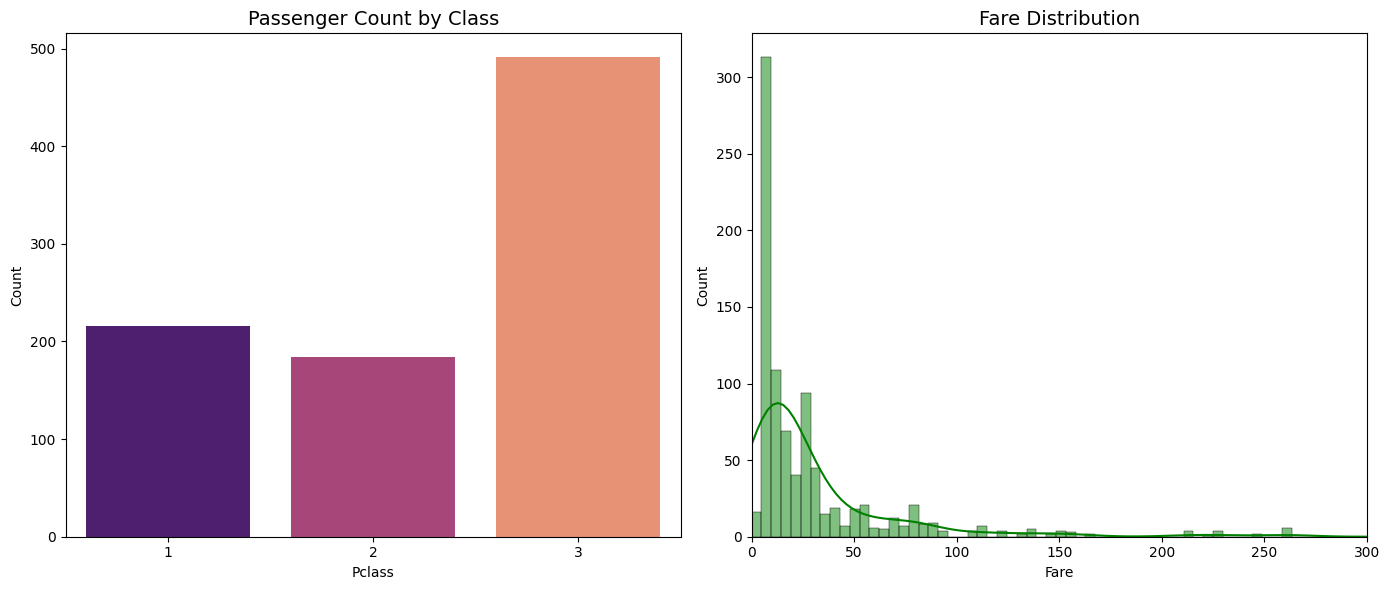

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Passenger Class Dist
sns.countplot(x='Pclass', data=df, palette='magma', ax=ax[0])
ax[0].set_title('Passenger Count by Class', fontsize=14)
ax[0].set_ylabel('Count')

# 2. Fare Distribution
sns.histplot(df['Fare'], kde=True, color='green', ax=ax[1])
ax[1].set_title('Fare Distribution', fontsize=14)
ax[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

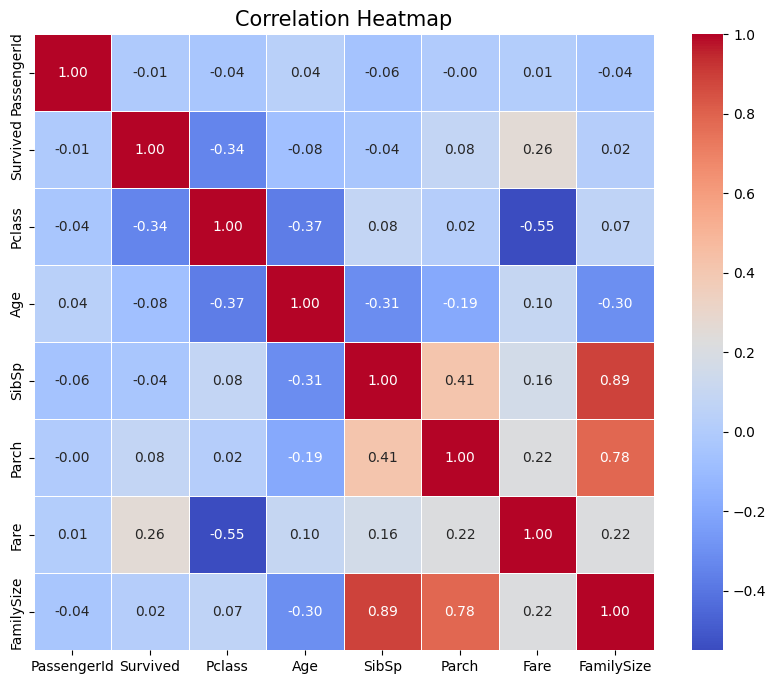

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=15)
plt.show()

In [ ]:
passenger_ids = df['PassengerId']
df_clean = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
df_clean = pd.get_dummies(df_clean, columns=['Embarked', 'Title'], drop_first=True)

2nd


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Titanic-Dataset (1).csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.duplicated()


,0
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [ ]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [ ]:
df[cat_col].nunique()

,0
Name,891
Sex,2
Ticket,681
Cabin,147
Embarked,3


In [ ]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

,0
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


In [ ]:
df1 = df.drop(columns=['Name', 'Ticket', 'Cabin'])
df1.dropna(subset=['Embarked'], inplace=True)
df1['Age'].fillna(df1['Age'].mean(), inplace=True)

/tmp/ipykernel_6430/56642916.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Age'].fillna(df1['Age'].mean(), inplace=True)


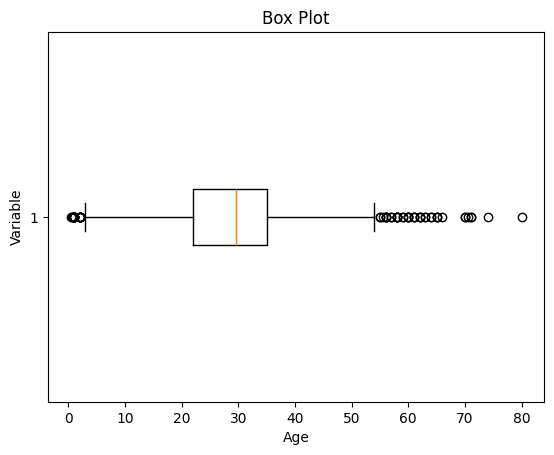

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df1['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

In [ ]:
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]

In [ ]:
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]

Lower Bound : 8.978989004171481
Upper Bound : 49.30395961288911


In [ ]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

num_col_ = [col for col in X.columns if X[col].dtype != 'object']
x1 = X
x1[num_col_] = scaler.fit_transform(x1[num_col_])
x1.head()

/tmp/ipykernel_6430/1761829158.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x1[num_col_] = scaler.fit_transform(x1[num_col_])


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.349515,0.125,0.0,0.014151,S
1,0.0,female,0.660194,0.125,0.0,0.139136,C
2,1.0,female,0.427184,0.000,0.0,0.015469,S
3,0.0,female,0.601942,0.125,0.0,0.103644,S
4,1.0,male,0.601942,0.000,0.0,0.015713,S


3rd


In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')
from sklearn import preprocessing
sns.set(style="darkgrid", color_codes=True)

In [ ]:
df=pd.read_csv('/content/Titanic-Dataset (1).csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.drop(columns=['Ticket',],inplace=True)
df.columns=['passengerid','survived','pclass','name','sex','age','sibsp','parch','fare','cabin','embarked']

passengerid     0.000000
survived        0.000000
pclass          0.000000
name            0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
cabin          77.104377
embarked        0.224467
dtype: float64


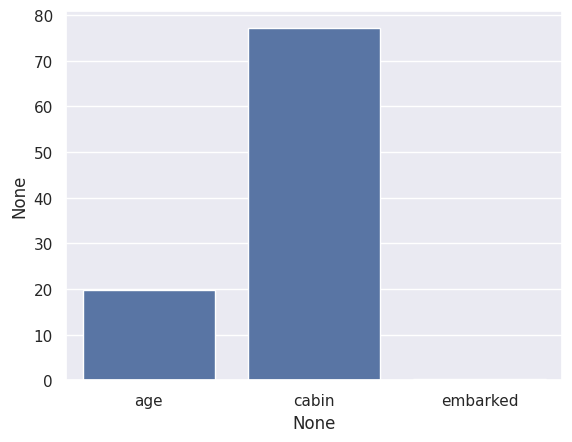

In [ ]:
null=df.isnull().sum()# entire
percent=null/len(df)*100
print(percent)
percent=percent[percent>0]
sns.barplot(x=percent.index,y=percent)
plt.show()

In [ ]:
print(df['embarked'].nunique())
print(df['embarked'].unique())

3
['S' 'C' 'Q' nan]


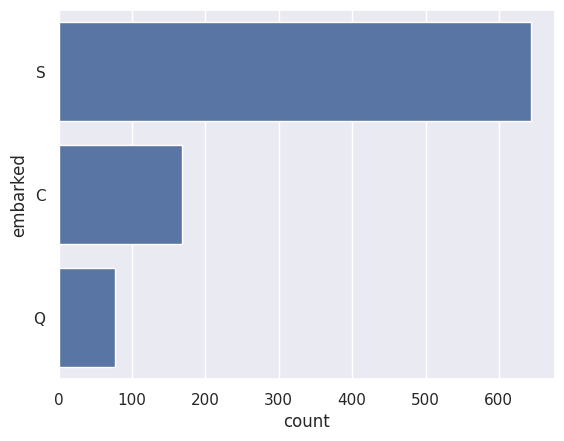

In [ ]:
df['embarked-s']=np.zeros(len(df))
df['embarked-c']=np.zeros(len(df))
df['embarked-q']=np.zeros(len(df))
sns.countplot(df['embarked'])
plt.show()

In [ ]:
# from the graph its fair assume the missing values to embarked=S
df['embarked'].fillna('S',inplace=True)
df.loc[df['embarked']=='S','embarked-s']=1
df.loc[df['embarked']=='C','embarked-c']=1
df.loc[df['embarked']=='Q','embarked-q']=1

In [ ]:
df.loc[df['sex']=='male','sex']=1
df.loc[df['sex']=='female','sex']=0
df['age'].fillna(df['age'].mean(),inplace=True)

In [ ]:
df['cabin'].nunique()

147

In [ ]:
df['owned_cabin']=df['cabin'].isnull().astype(int)
df['is_minor']=np.zeros(len(df))
df.loc[df['age']<18,'is_minor']=1

df['pclass_1']=np.zeros(len(df))
df['pclass_2']=np.zeros(len(df))
df['pclass_3']=np.zeros(len(df))
df.loc[df['pclass']==1,'pclass_1']=1
df.loc[df['pclass']==2,'pclass_2']=1
df.loc[df['pclass']==3,'pclass_3']=1


In [ ]:
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare,embarked-s,embarked-c,embarked-q,owned_cabin,is_minor,pclass_1,pclass_2,pclass_3
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.725028,0.188552,0.086420,0.771044,0.126824,0.242424,0.206510,0.551066
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429,0.446751,0.391372,0.281141,0.420397,0.332962,0.428790,0.405028,0.497665
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


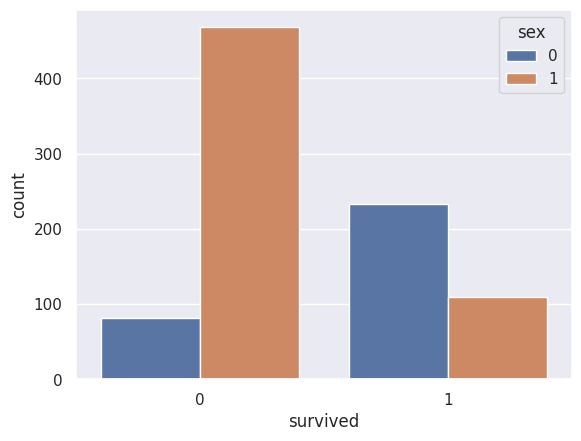

In [ ]:
sns.countplot(data=df,x='survived',hue='sex')
plt.show()


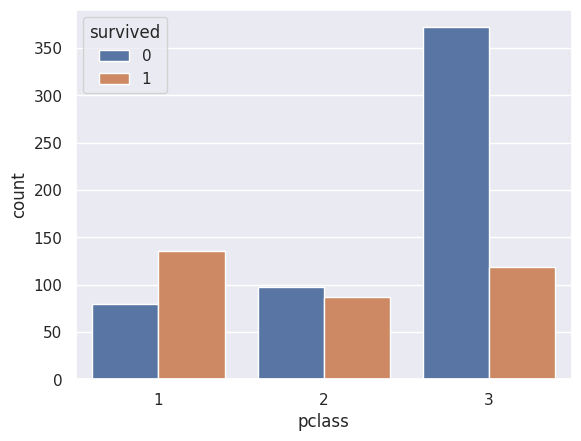

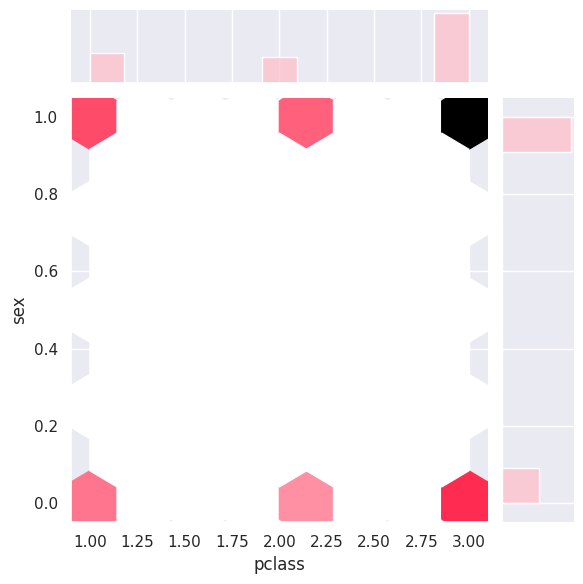

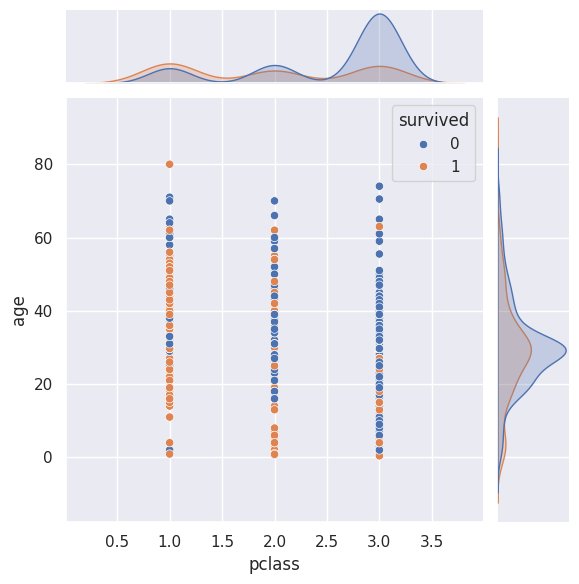

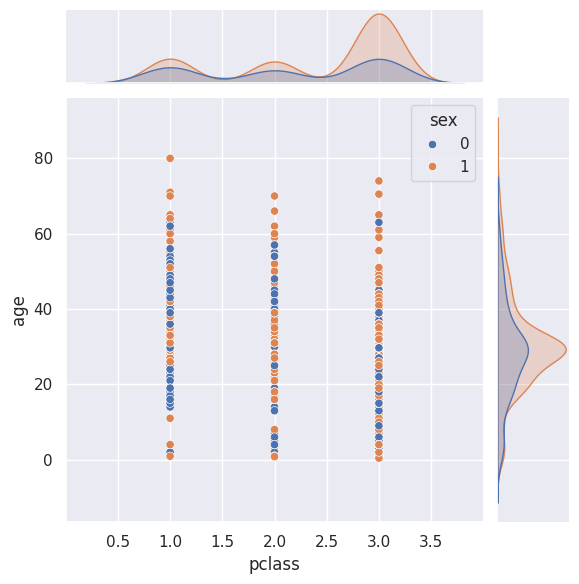

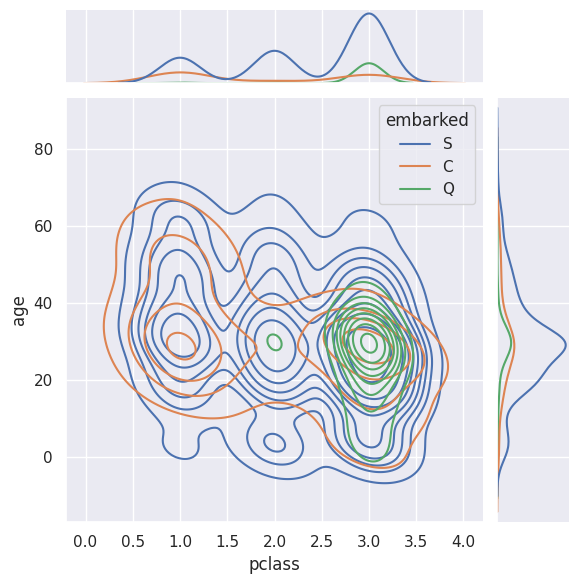

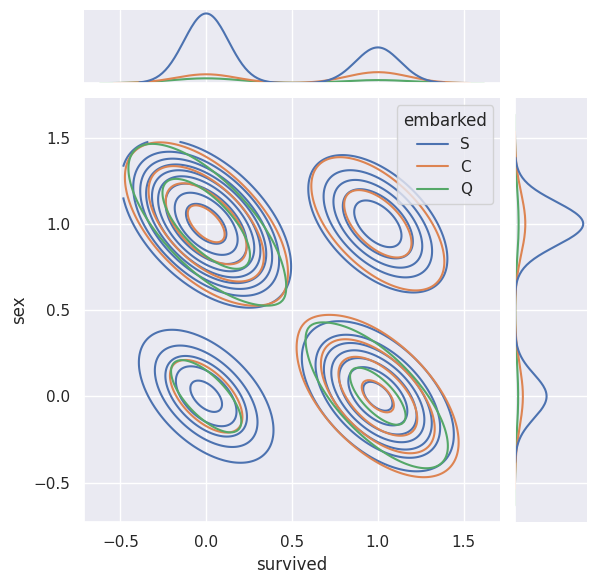

In [ ]:
sns.set(style='darkgrid')
sns.countplot(x='pclass', hue='survived', data=df)
sns.jointplot(x='pclass', y='sex', data=df, kind='hex', color='pink')
sns.jointplot(x='pclass', y='age', hue='survived', data=df)
sns.jointplot(x='pclass', y='age', hue='sex', data=df)
sns.jointplot(x='pclass', y='age', hue='embarked', data=df, kind='kde')
sns.jointplot(x='survived', y='sex', hue='embarked', data=df, kind='kde')
plt.show()

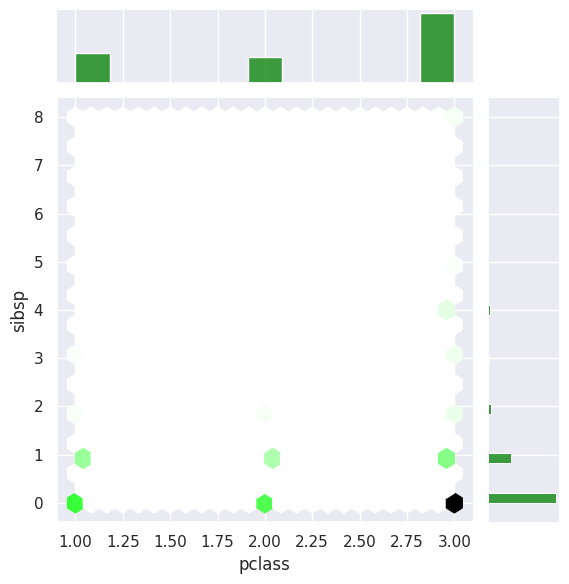

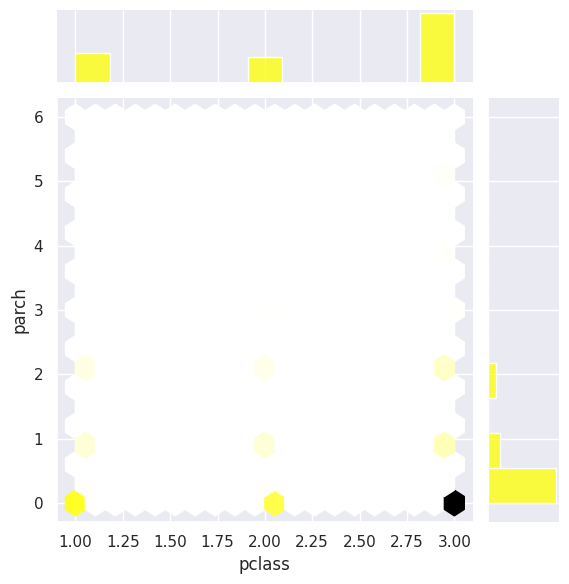

In [ ]:
sns.jointplot(x='pclass', y='sibsp', data=df, kind='hex', color='green')
sns.jointplot(x='pclass', y='parch', data=df, kind='hex', color='yellow')
plt.show()

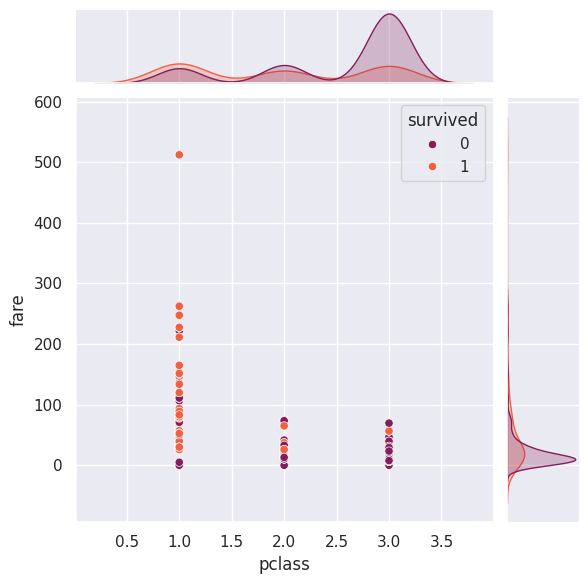

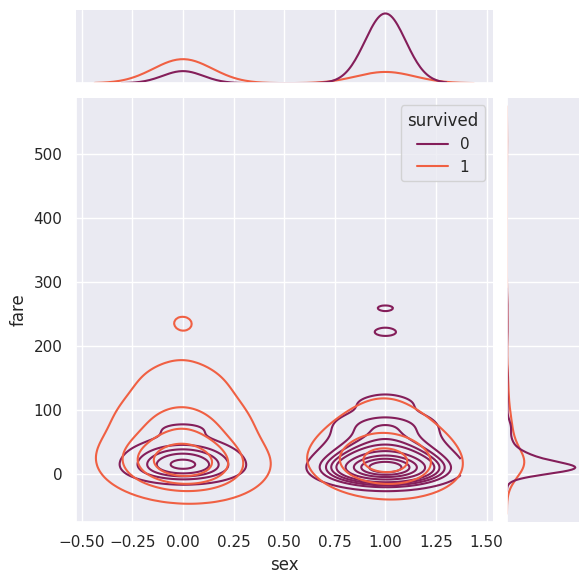

In [ ]:
sns.jointplot(x='pclass', y='fare', hue='survived', data=df, palette='rocket')
sns.jointplot(x='sex', y='fare', hue='survived', data=df, kind='kde', palette ='rocket')

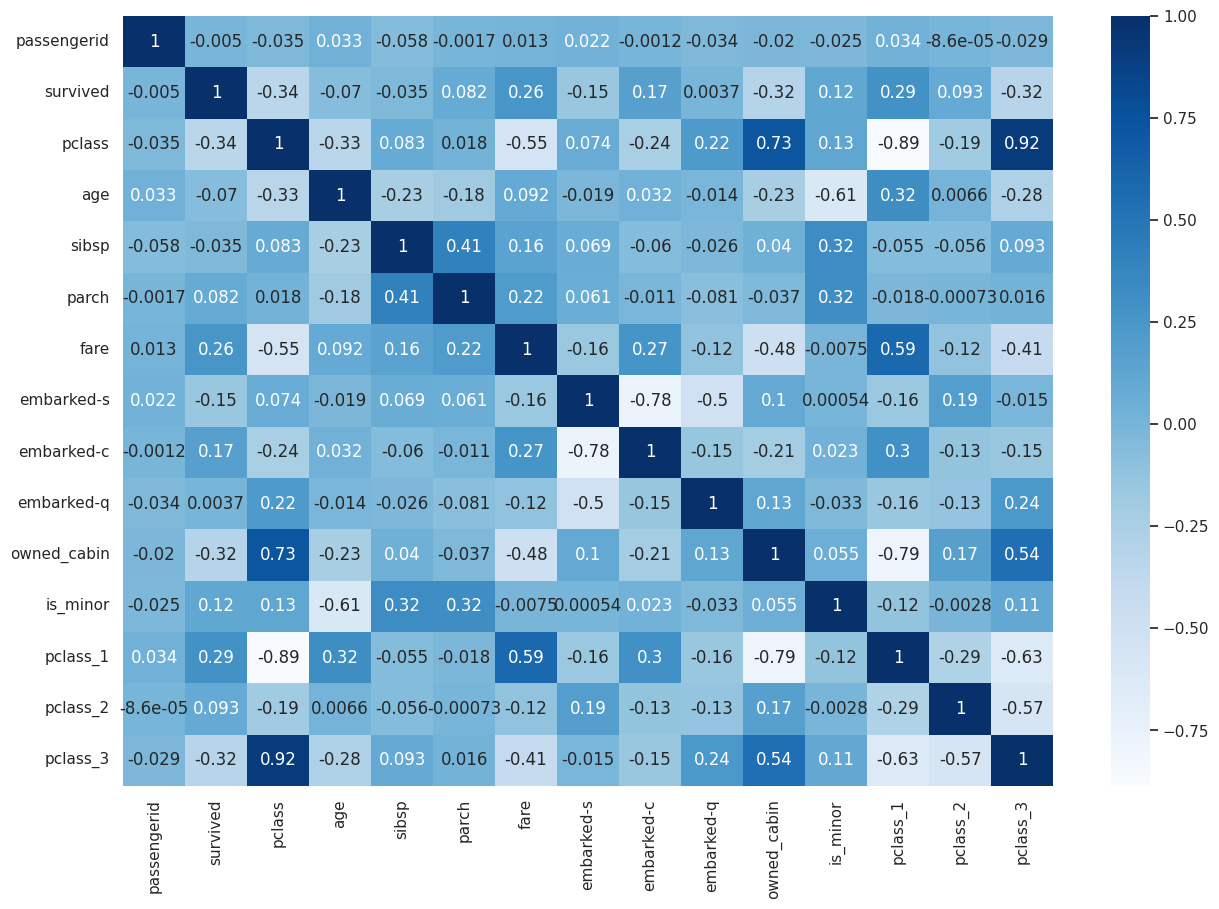

In [ ]:
corr_matrix=df.corr(numeric_only=True)
figure=plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix,annot=True,cmap='Blues')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.svm import LinearSVC,SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn

In [ ]:
df.drop(columns={'pclass','name','cabin','embarked'},inplace=True)
df.head()

,passengerid,survived,sex,age,sibsp,parch,fare,embarked-s,embarked-c,embarked-q,owned_cabin,is_minor,pclass_1,pclass_2,pclass_3
0,1,0,1,22.0,1,0,7.2500,1.0,0.0,0.0,1,0.0,0.0,0.0,1.0
1,2,1,0,38.0,1,0,71.2833,0.0,1.0,0.0,0,0.0,1.0,0.0,0.0
2,3,1,0,26.0,0,0,7.9250,1.0,0.0,0.0,1,0.0,0.0,0.0,1.0
3,4,1,0,35.0,1,0,53.1000,1.0,0.0,0.0,0,0.0,1.0,0.0,0.0
4,5,0,1,35.0,0,0,8.0500,1.0,0.0,0.0,1,0.0,0.0,0.0,1.0


In [ ]:
X=df.drop(columns={'survived','is_minor'}, axis=1)
Y=df['survived']
train_x,validation_x,train_y,validation_y=train_test_split(X,Y.to_numpy(),test_size=0.2,random_state=10)

In [ ]:
clf=LinearSVC(C=0.1,random_state=0)
clf.fit(train_x,train_y)
y_preds=clf.predict(validation_x)
accuracy=accuracy_score(validation_y,y_preds)
print(accuracy)

0.8379888268156425


In [ ]:
confusion_matrix(validation_y,y_preds)

array([[105,  12],
       [ 17,  45]])

In [ ]:
param_grid = {'C': 10. ** np.arange(-10, 4)}
grid_search = GridSearchCV(clf, param_grid=param_grid, cv=6,)
grid_search.fit(train_x,train_y)

GridSearchCV(cv=6, estimator=LinearSVC(C=0.1, random_state=0),
             param_grid={'C': array([1.e-10, 1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03,
       1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])})

In [ ]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': np.float64(0.1)}
0.7992332526230831


In [ ]:
res_data=pd.DataFrame(grid_search.cv_results_)
res_data

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004333,0.001118,0.002008,0.000161,1.000000e-10,{'C': 1e-10},0.605042,0.605042,0.605042,0.605042,0.610169,0.610169,0.606751,0.002417,13
1,0.003594,0.000030,0.001871,0.000058,1.000000e-09,{'C': 1e-09},0.605042,0.605042,0.605042,0.605042,0.610169,0.610169,0.606751,0.002417,13
2,0.003844,0.000076,0.001952,0.000071,1.000000e-08,{'C': 1e-08},0.605042,0.613445,0.613445,0.605042,0.610169,0.610169,0.609552,0.003458,11
3,0.003734,0.000067,0.001874,0.000011,1.000000e-07,{'C': 1e-07},0.579832,0.605042,0.605042,0.630252,0.644068,0.584746,0.608164,0.022904,12
4,0.003753,0.000108,0.002043,0.000358,1.000000e-06,{'C': 1e-06},0.638655,0.647059,0.596639,0.647059,0.618644,0.601695,0.624958,0.020606,10
5,0.003880,0.000225,0.001942,0.000107,1.000000e-05,{'C': 1e-05},0.672269,0.638655,0.588235,0.621849,0.635593,0.618644,0.629208,0.025261,9
6,0.004212,0.000096,0.001925,0.000035,1.000000e-04,{'C': 0.0001},0.680672,0.689076,0.613445,0.630252,0.669492,0.644068,0.654501,0.027348,8
7,0.004334,0.000106,0.001896,0.000034,1.000000e-03,{'C': 0.001},0.705882,0.697479,0.672269,0.689076,0.728814,0.703390,0.699485,0.017173,7
8,0.005277,0.000529,0.002194,0.000222,1.000000e-02,{'C': 0.01},0.764706,0.857143,0.764706,0.722689,0.788136,0.830508,0.787981,0.044607,6
9,0.005059,0.000346,0.001953,0.000113,1.000000e-01,{'C': 0.1},0.789916,0.865546,0.756303,0.731092,0.813559,0.838983,0.799233,0.046108,1


4th


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('/Titanic-Dataset.csv')
print('Dataset Loaded Successfully')

Dataset Loaded Successfully


In [6]:
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


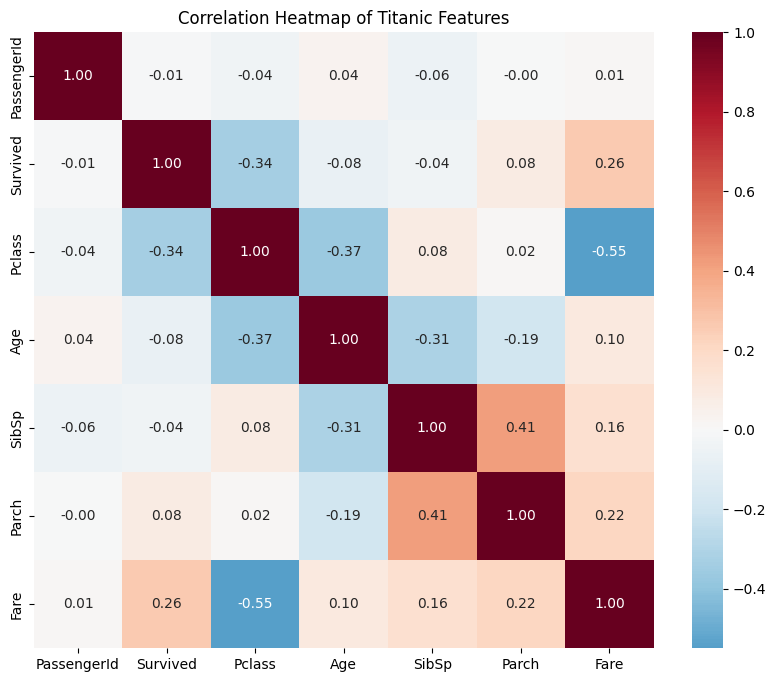

In [8]:
numeric_df = df.select_dtypes(include=['number'])

# 1. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 2. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')

plt.title('Correlation Heatmap of Titanic Features')
plt.show()

5th

In [10]:
import numpy as np # linear algebra
import pandas as pd

In [9]:
import os
for dirname, _, filenames in os.walk('/Titanic-Dataset.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Titanic-Dataset.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [13]:
df[cat_col].nunique()

,0
Name,891
Sex,2
Ticket,681
Cabin,147
Embarked,3


In [14]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

,0
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


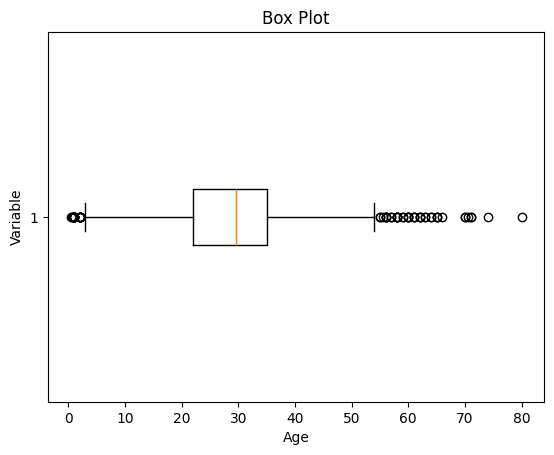

In [16]:
import matplotlib.pyplot as plt

plt.boxplot(df1['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

In [17]:
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]

In [18]:
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [19]:
mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]

Lower Bound : 8.978989004171481
Upper Bound : 49.30395961288911


In [20]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']

5th

In [21]:
import pandas as pd

df = pd.read_csv("/Titanic-Dataset.csv")

df.head()

df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Check remaining columns
print(df.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [22]:
df.shape

(891, 8)

In [23]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [25]:
import pandas as pd

df = pd.read_csv("/Titanic-Dataset.csv")
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin','Embarked','Parch','SibSp'], axis=1)

# Check remaining columns
print(df.columns)

# Check missing values
print(df.isnull().sum())

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare'], dtype='object')
Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
dtype: int64


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   Fare      891 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 34.9+ KB


In [27]:
print(df.isnull().sum())

Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
dtype: int64


In [28]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
dtype: int64


6th

In [29]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config Completer.use_jedi = False
import warnings
warnings.simplefilter(action='ignore')
from sklearn import preprocessing
sns.set(style="darkgrid", color_codes=True)

In [30]:
df=pd.read_csv('/Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [31]:
df.drop(columns=['Ticket',],inplace=True)
df.columns=['passengerid','survived','pclass','name','sex','age','sibsp','parch','fare','cabin','embarked']

passengerid     0.000000
survived        0.000000
pclass          0.000000
name            0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
cabin          77.104377
embarked        0.224467
dtype: float64


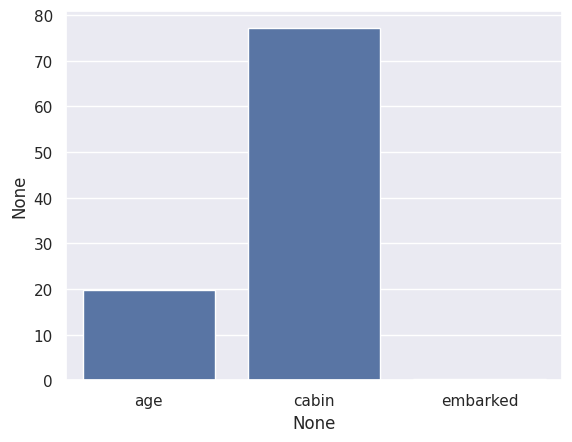

In [32]:
null=df.isnull().sum()# entire
percent=null/len(df)*100
print(percent)
percent=percent[percent>0]
sns.barplot(x=percent.index,y=percent)
plt.show()

In [33]:
print(df['embarked'].nunique())
print(df['embarked'].unique())

3
['S' 'C' 'Q' nan]


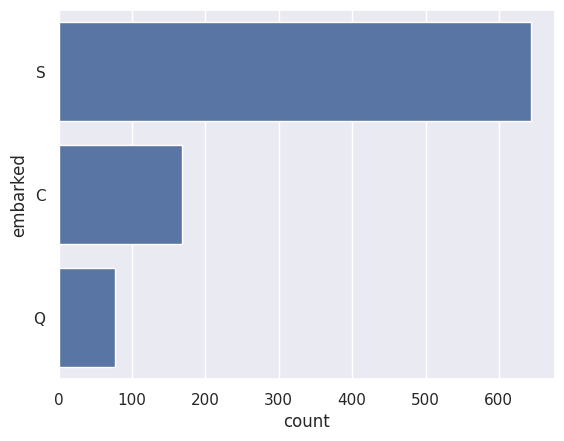

In [34]:
df['embarked-s']=np.zeros(len(df))
df['embarked-c']=np.zeros(len(df))
df['embarked-q']=np.zeros(len(df))
sns.countplot(df['embarked'])
plt.show()

In [35]:
df['embarked'].fillna('S',inplace=True)
df.loc[df['embarked']=='S','embarked-s']=1
df.loc[df['embarked']=='C','embarked-c']=1
df.loc[df['embarked']=='Q','embarked-q']=1

In [36]:
df.loc[df['sex']=='male','sex']=1
df.loc[df['sex']=='female','sex']=0
df['age'].fillna(df['age'].mean(),inplace=True)

In [37]:
df['cabin'].nunique()

147

In [38]:
df['owned_cabin']=df['cabin'].isnull().astype(int)
df['is_minor']=np.zeros(len(df))
df.loc[df['age']<18,'is_minor']=1

df['pclass_1']=np.zeros(len(df))
df['pclass_2']=np.zeros(len(df))
df['pclass_3']=np.zeros(len(df))
df.loc[df['pclass']==1,'pclass_1']=1
df.loc[df['pclass']==2,'pclass_2']=1
df.loc[df['pclass']==3,'pclass_3']=1

In [39]:
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare,embarked-s,embarked-c,embarked-q,owned_cabin,is_minor,pclass_1,pclass_2,pclass_3
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.725028,0.188552,0.086420,0.771044,0.126824,0.242424,0.206510,0.551066
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429,0.446751,0.391372,0.281141,0.420397,0.332962,0.428790,0.405028,0.497665
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


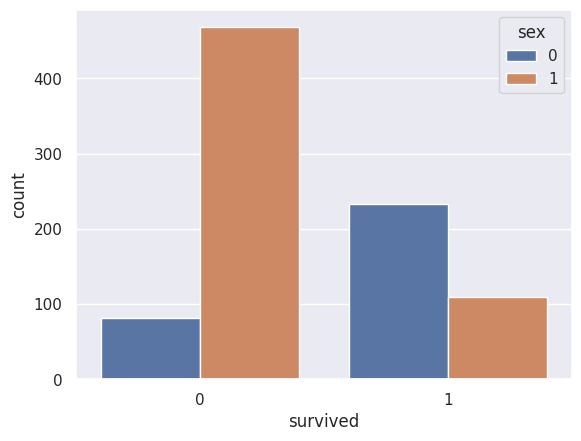

In [40]:
sns.countplot(data=df,x='survived',hue='sex')
plt.show()

7th

In [42]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd

In [43]:
df1.head(5)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [45]:
df.sample(5)

,passengerid,survived,pclass,name,sex,age,sibsp,parch,fare,cabin,embarked,embarked-s,embarked-c,embarked-q,owned_cabin,is_minor,pclass_1,pclass_2,pclass_3
341,342,1,1,"Fortune, Miss. Alice Elizabeth",0,24.000000,3,2,263.000,C23 C25 C27,S,1.0,0.0,0.0,0,0.0,1.0,0.0,0.0
27,28,0,1,"Fortune, Mr. Charles Alexander",1,19.000000,3,2,263.000,C23 C25 C27,S,1.0,0.0,0.0,0,0.0,1.0,0.0,0.0
226,227,1,2,"Mellors, Mr. William John",1,19.000000,0,0,10.500,NaN,S,1.0,0.0,0.0,1,0.0,0.0,1.0,0.0
168,169,0,1,"Baumann, Mr. John D",1,29.699118,0,0,25.925,NaN,S,1.0,0.0,0.0,1,0.0,1.0,0.0,0.0
11,12,1,1,"Bonnell, Miss. Elizabeth",0,58.000000,0,0,26.550,C103,S,1.0,0.0,0.0,0,0.0,1.0,0.0,0.0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          891 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   fare         891 non-null    float64
 9   cabin        204 non-null    object 
 10  embarked     891 non-null    object 
 11  embarked-s   891 non-null    float64
 12  embarked-c   891 non-null    float64
 13  embarked-q   891 non-null    float64
 14  owned_cabin  891 non-null    int64  
 15  is_minor     891 non-null    float64
 16  pclass_1     891 non-null    float64
 17  pclass_2     891 non-null    float64
 18  pclass_3     891 non-null    float64
dtypes: float

In [47]:
df.isnull().sum()

,0
passengerid,0
survived,0
pclass,0
name,0
sex,0
age,0
sibsp,0
parch,0
fare,0
cabin,687


In [48]:
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare,embarked-s,embarked-c,embarked-q,owned_cabin,is_minor,pclass_1,pclass_2,pclass_3
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.725028,0.188552,0.086420,0.771044,0.126824,0.242424,0.206510,0.551066
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429,0.446751,0.391372,0.281141,0.420397,0.332962,0.428790,0.405028,0.497665
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.select_dtypes(include=['number']).corr()

,passengerid,survived,pclass,age,sibsp,parch,fare,embarked-s,embarked-c,embarked-q,owned_cabin,is_minor,pclass_1,pclass_2,pclass_3
passengerid,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658,0.022204,-0.001205,-0.033606,-0.019919,-0.024874,0.034303,-0.000086,-0.029486
survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307,-0.149683,0.168240,0.003650,-0.316912,0.122239,0.285904,0.093349,-0.322308
pclass,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500,0.074053,-0.243292,0.221009,0.725541,0.125620,-0.885924,-0.188432,0.916673
age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566,-0.019336,0.032024,-0.013855,-0.233123,-0.605852,0.319916,0.006589,-0.281004
sibsp,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651,0.068734,-0.059528,-0.026354,0.040460,0.324068,-0.054582,-0.055932,0.092548
parch,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225,0.060814,-0.011069,-0.081228,-0.036987,0.317670,-0.017633,-0.000734,0.015790
fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000,-0.162184,0.269335,-0.117216,-0.482075,-0.007546,0.591711,-0.118557,-0.413333
embarked-s,0.022204,-0.149683,0.074053,-0.019336,0.068734,0.060814,-0.162184,1.000000,-0.782742,-0.499421,0.101139,0.000543,-0.161921,0.189980,-0.015104
embarked-c,-0.001205,0.168240,-0.243292,0.032024,-0.059528,-0.011069,0.269335,-0.782742,1.000000,-0.148258,-0.208528,0.023225,0.296423,-0.125416,-0.153329
embarked-q,-0.033606,0.003650,0.221009,-0.013855,-0.026354,-0.081228,-0.117216,-0.499421,-0.148258,1.000000,0.129572,-0.033194,-0.155342,-0.127301,0.237449
